# MDCE Autopilot Notebook

Project: **Motorsport Decision Confidence Engine (MDCE)**

This notebook is a start-to-end Colab runbook. It uses your uploaded Drive datasets, extracts every uploaded zip, loads every readable CSV/parquet into SQLite, includes the uploaded 4 GB Hugging Face parquet in full-data mode, creates the database, validates real pit decisions, trains an ML pit-window model, runs a 2023 backtest, saves charts, and writes final evidence reports.

The heavy SQLite build now happens on Colab local disk at `/content/mdce_f1_work.db` first, then the finished database is copied back to Drive. This avoids slow Drive writes during the biggest data-loading step.

MDCE is not only a pit-stop project. Pit timing is the first public-data validation case because actual pit stops are available for checking. The same confidence/risk layer can later extend to tyre choice, stint length, push/conserve decisions, safety-car response, weather uncertainty, and aggressive vs safe strategy calls.


## Run Checklist

Before pressing **Runtime > Run all**, check this once:

- Your Google Drive contains `/MyDrive/ibm_project_stuff/MDCE`.
- Your zip files and parquet folders are inside `/MyDrive/ibm_project_stuff/MDCE/data/raw/zips`.
- The notebook is folder-locked: it only reads/writes inside that MDCE project folder and does not search the rest of `MyDrive`.
- The expected main datasets are present: Kaggle weather/tyre, Kaggle jtrotman F1 race data, Kaggle rohanrao F1 world championship, F1DB CSV, Mendeley safety-car/risk dataset, and the uploaded Hugging Face parquet data.
- Full dataset mode is on. The 4 GB parquet can take time, but it is loaded in smaller batches to reduce RAM crashes.
- Run this notebook top to bottom. If any cell fails, send the full traceback and the last printed step name.


## What This Notebook Produces

Outputs will be written under your Drive folder:

- `outputs/reports/mdce_raw_upload_inventory.csv`: every raw uploaded file detected.
- `outputs/reports/mdce_ingestion_audit.csv`: every load attempt, including loaded/missing/failed status.
- `databases/mdce_f1.db`: copied final SQLite database with loaded source tables, extra tables, training rows, and model predictions.
- `data/processed/pit_training_rows.parquet`: ML training table.
- `outputs/models/pit_window_random_forest.joblib`: trained model.
- `outputs/reports/*.json`, `*.csv`, `*.md`: metrics, validation, ingestion, and final evidence report.
- `outputs/charts/*.png`: charts for presentation and documentation.

The important final file is:

`/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/mdce_final_evidence_report.md`


## 1. Mount Google Drive

Run this first. Colab will ask for permission. After Drive is mounted, the rest of the notebook only uses the locked MDCE project path.


In [1]:
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


## 2. Install Runtime Dependencies

These are normal Python packages used for data loading, parquet batch reading, SQLite export, model training, charts, and model saving.


In [2]:
%pip install -q pandas numpy pyarrow scikit-learn matplotlib seaborn joblib


## 3. Autopilot Pipeline

The following cells are ordered so **Run all** can keep working by itself. Configuration is near the top of the next code cell:

- `FULL_DATASET_MODE = True` extracts and scans all uploaded zips/folders.
- `RUN_HEAVY_HUGGINGFACE_TABLE = True` includes the uploaded 4 GB parquet data.
- `PARQUET_BATCH_ROWS = 5_000` keeps memory lower while loading heavy parquet files.
- The SQLite DB is built locally at `/content/mdce_f1_work.db`, then copied back to Drive.


### 3.0 Configuration, Imports, and Helper Functions

This cell sets the Drive paths, creates output folders, enables full dataset mode, defines dataset-name fallbacks, uses a local working SQLite DB for speed, and defines helper functions used by later cells.


In [3]:
from pathlib import Path
import gc
import hashlib
import json
import re
import shutil
import sqlite3
import zipfile

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)

DRIVE_ROOT = Path("/content/drive/MyDrive/ibm_project_stuff/MDCE")
if not DRIVE_ROOT.exists():
    raise FileNotFoundError(
        "Expected project folder not found: "
        f"{DRIVE_ROOT}. This notebook is intentionally locked to the MDCE folder "
        "and will not scan the rest of MyDrive."
    )

ZIP_DIR = DRIVE_ROOT / "data" / "raw" / "zips"
EXTRACTED_DIR = DRIVE_ROOT / "data" / "raw" / "extracted"
PROCESSED_DIR = DRIVE_ROOT / "data" / "processed"
DB_DIR = DRIVE_ROOT / "databases"
REPORT_DIR = DRIVE_ROOT / "outputs" / "reports"
CHART_DIR = DRIVE_ROOT / "outputs" / "charts"
MODEL_DIR = DRIVE_ROOT / "outputs" / "models"
SCREENSHOT_DIR = DRIVE_ROOT / "outputs" / "screenshots"
EXTRA_EXTRACTED_DIR = EXTRACTED_DIR / "_extra_uploaded_zips"

for folder in [ZIP_DIR, EXTRACTED_DIR, EXTRA_EXTRACTED_DIR, PROCESSED_DIR, DB_DIR, REPORT_DIR, CHART_DIR, MODEL_DIR, SCREENSHOT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

DRIVE_DB_PATH = DB_DIR / "mdce_f1.db"
DB_PATH = Path("/content/mdce_f1_work.db")
if DB_PATH.exists():
    DB_PATH.unlink()

# Full dataset mode means: extract every uploaded zip, scan every extracted
# CSV/parquet, load every readable table into SQLite, and keep an ingestion log.
FULL_DATASET_MODE = True

# This project now intentionally includes the uploaded 4 GB Hugging Face parquet.
# The loader uses parquet batches to reduce memory pressure, but Colab can still
# take time because SQLite writes are slow for multi-GB tables.
RUN_HEAVY_HUGGINGFACE_TABLE = True
PARQUET_BATCH_ROWS = 5_000
CSV_CHUNK_ROWS = 50_000


ZIP_ALIASES = {
    "kaggle-naven-weather-tyre-features.zip": ["kaggle-naven-weather-tyre-features.zip", "archive.zip"],
    "kaggle-jtrotman-formula-1-race-data.zip": ["kaggle-jtrotman-formula-1-race-data.zip", "archive (1).zip"],
    "kaggle-rohanrao-f1-world-championship.zip": ["kaggle-rohanrao-f1-world-championship.zip", "Formula 1 World Championship (1950 - 2024).zip"],
    "f1db-csv.zip": ["f1db-csv.zip"],
    "mendeley-multi-season-f1-lap-safety-car.zip": ["mendeley-multi-season-f1-lap-safety-car.zip", "Multi-Season Formula 1 Lap Dataset with Race-Contr.zip"],
}

LOADED_FILE_PATHS = set()
INGESTION_LOG = []


def clean_table_name(name):
    name = name.lower()
    name = re.sub(r"[^a-z0-9_]+", "_", name)
    name = re.sub(r"_+", "_", name).strip("_")
    return name


def find_zip(canonical_name):
    for name in ZIP_ALIASES.get(canonical_name, [canonical_name]):
        path = ZIP_DIR / name
        if path.exists():
            return path
    return ZIP_DIR / canonical_name


def find_named_file(root, file_name):
    root = Path(root)
    direct = root / file_name
    if direct.exists():
        return direct
    matches = list(root.rglob(file_name))
    return matches[0] if matches else direct


def find_first_by_suffix(root, suffix):
    root = Path(root)
    matches = sorted(path for path in root.rglob(f"*{suffix}") if path.is_file())
    return matches[0] if matches else None


def path_size_mb(path):
    path = Path(path)
    return round(path.stat().st_size / (1024 * 1024), 3) if path.exists() else None


def resolve_key(path):
    try:
        return str(Path(path).resolve())
    except Exception:
        return str(Path(path))


def table_exists(conn, table_name):
    row = conn.execute("SELECT name FROM sqlite_master WHERE type='table' AND name = ?", (table_name,)).fetchone()
    return row is not None


def unique_table_name(conn, base_name):
    base_name = clean_table_name(base_name) or "table"
    table_name = base_name[:120].rstrip("_")
    if not table_exists(conn, table_name):
        return table_name
    suffix = 2
    while True:
        candidate = f"{table_name[:110].rstrip('_')}_{suffix}"
        if not table_exists(conn, candidate):
            return candidate
        suffix += 1


def table_name_from_path(path, prefix="auto"):
    path = Path(path)
    try:
        rel = path.relative_to(DRIVE_ROOT)
    except ValueError:
        rel = path
    digest = hashlib.md5(str(rel).encode("utf-8")).hexdigest()[:8]
    stem = clean_table_name(str(rel.with_suffix("")).replace("/", "_"))
    base = f"{prefix}_{stem}"
    if len(base) > 120:
        base = f"{base[:105].rstrip('_')}_{digest}"
    return clean_table_name(base)


def record_ingestion(path, table_name, status, rows=None, columns=None, error=None):
    INGESTION_LOG.append(
        {
            "path": str(path),
            "table": table_name,
            "status": status,
            "rows": int(rows) if rows is not None and not pd.isna(rows) else None,
            "columns": int(columns) if columns is not None and not pd.isna(columns) else None,
            "size_mb": path_size_mb(path),
            "error": str(error)[:1000] if error else None,
        }
    )


def prepare_sqlite_frame(df):
    df = df.copy()
    df.columns = [clean_table_name(str(col)) or f"col_{idx}" for idx, col in enumerate(df.columns)]
    seen = {}
    fixed_cols = []
    for col in df.columns:
        if col not in seen:
            seen[col] = 0
            fixed_cols.append(col)
        else:
            seen[col] += 1
            fixed_cols.append(f"{col}_{seen[col]}")
    df.columns = fixed_cols
    object_cols = df.select_dtypes(include=["object"]).columns
    for col in object_cols:
        if df[col].map(lambda value: isinstance(value, (list, dict, tuple, set, np.ndarray))).any():
            df[col] = df[col].map(lambda value: json.dumps(value, default=str) if isinstance(value, (list, dict, tuple, set, np.ndarray)) else value)
    return df


def load_csv_to_db(conn, path, table_name, required=False, normalize_columns=False, dedupe_table_name=False):
    path = Path(path)
    if not path.exists():
        print("missing:", path)
        record_ingestion(path, table_name, "missing")
        if required:
            raise FileNotFoundError(path)
        return None
    table_name = clean_table_name(table_name)
    if dedupe_table_name:
        table_name = unique_table_name(conn, table_name)
    total_rows = 0
    columns = None
    try:
        first = True
        for chunk in pd.read_csv(path, low_memory=False, chunksize=CSV_CHUNK_ROWS):
            if normalize_columns:
                chunk = prepare_sqlite_frame(chunk)
            columns = len(chunk.columns)
            chunk.to_sql(table_name, conn, if_exists="replace" if first else "append", index=False)
            total_rows += len(chunk)
            del chunk
            gc.collect()
            first = False
        if first:
            empty_df = pd.read_csv(path, low_memory=False)
            if normalize_columns:
                empty_df = prepare_sqlite_frame(empty_df)
            columns = len(empty_df.columns)
            empty_df.to_sql(table_name, conn, if_exists="replace", index=False)
            del empty_df
            gc.collect()
        LOADED_FILE_PATHS.add(resolve_key(path))
        record_ingestion(path, table_name, "loaded", total_rows, columns)
        print("loaded:", table_name, (total_rows, columns))
        return {"table": table_name, "rows": total_rows, "columns": columns}
    except Exception as exc:
        record_ingestion(path, table_name, "failed", total_rows if total_rows else None, columns, exc)
        print("could not load:", path, exc)
        if required:
            raise
        return None


def load_parquet_to_db(conn, path, table_name, required=False, normalize_columns=False, dedupe_table_name=False):
    path = Path(path)
    if not path.exists():
        print("missing:", path)
        record_ingestion(path, table_name, "missing")
        if required:
            raise FileNotFoundError(path)
        return None
    if path_size_mb(path) and path_size_mb(path) > 1000 and not RUN_HEAVY_HUGGINGFACE_TABLE:
        record_ingestion(path, table_name, "skipped_heavy_file", error="RUN_HEAVY_HUGGINGFACE_TABLE is False")
        print("skipped heavy parquet:", path)
        return None
    table_name = clean_table_name(table_name)
    if dedupe_table_name:
        table_name = unique_table_name(conn, table_name)
    total_rows = 0
    columns = None
    try:
        parquet_file = pq.ParquetFile(path)
        first = True
        for batch in parquet_file.iter_batches(batch_size=PARQUET_BATCH_ROWS):
            chunk = batch.to_pandas(split_blocks=True, self_destruct=True)
            if normalize_columns:
                chunk = prepare_sqlite_frame(chunk)
            columns = len(chunk.columns)
            chunk.to_sql(table_name, conn, if_exists="replace" if first else "append", index=False)
            total_rows += len(chunk)
            del chunk
            gc.collect()
            first = False
            if total_rows and total_rows % 500000 == 0:
                print("  parquet rows loaded:", table_name, total_rows)
        if first:
            empty_df = parquet_file.read().to_pandas()
            if normalize_columns:
                empty_df = prepare_sqlite_frame(empty_df)
            columns = len(empty_df.columns)
            empty_df.to_sql(table_name, conn, if_exists="replace", index=False)
            del empty_df
            gc.collect()
        LOADED_FILE_PATHS.add(resolve_key(path))
        record_ingestion(path, table_name, "loaded", total_rows, columns)
        print("loaded:", table_name, (total_rows, columns))
        return {"table": table_name, "rows": total_rows, "columns": columns}
    except Exception as exc:
        record_ingestion(path, table_name, "failed", total_rows if total_rows else None, columns, exc)
        print("could not load:", path, exc)
        if required:
            raise
        return None


def safe_int(value, default=None):
    try:
        if pd.isna(value):
            return default
        return int(value)
    except Exception:
        return default


def trend(series):
    values = list(series)
    if len(values) < 2:
        return 0.0
    return (values[-1] - values[0]) / max(1, len(values) - 1)


def write_json(path, obj):
    Path(path).write_text(json.dumps(obj, indent=2, default=str), encoding="utf-8")
    print("wrote:", path)


print("DRIVE_ROOT:", DRIVE_ROOT)
print("ZIP_DIR:", ZIP_DIR)
print("WORKING_DB_PATH:", DB_PATH)
print("DRIVE_DB_PATH:", DRIVE_DB_PATH)


DRIVE_ROOT: /content/drive/MyDrive/ibm_project_stuff/MDCE
ZIP_DIR: /content/drive/MyDrive/ibm_project_stuff/MDCE/data/raw/zips
WORKING_DB_PATH: /content/mdce_f1_work.db
DRIVE_DB_PATH: /content/drive/MyDrive/ibm_project_stuff/MDCE/databases/mdce_f1.db


### 3.1 Raw upload inventory and expected file check

This cell runs pipeline step 1. It prints progress and writes generated artifacts to Drive.


In [4]:
print("\nSTEP 1: raw file check")
raw_inventory = []
for path in sorted(ZIP_DIR.rglob("*")):
    if not path.is_file():
        continue
    item = {
        "path": str(path),
        "name": path.name,
        "suffix": path.suffix.lower(),
        "size_mb": path_size_mb(path),
    }
    raw_inventory.append(item)
    print("-", path.relative_to(ZIP_DIR), item["size_mb"], "MB")
pd.DataFrame(raw_inventory).to_csv(REPORT_DIR / "mdce_raw_upload_inventory.csv", index=False)
write_json(REPORT_DIR / "mdce_raw_upload_inventory.json", raw_inventory)

expected_files = [
    "kaggle-naven-weather-tyre-features.zip",
    "kaggle-jtrotman-formula-1-race-data.zip",
    "kaggle-rohanrao-f1-world-championship.zip",
    "f1db-csv.zip",
    "mendeley-multi-season-f1-lap-safety-car.zip",
]
missing_expected = [name for name in expected_files if not find_zip(name).exists()]
if missing_expected:
    print("WARNING missing expected files:", missing_expected)



STEP 1: raw file check
- f1_dataset.parquet 4078.0 MB
- f1db-csv.zip 4.236 MB
- kaggle-jtrotman-formula-1-race-data.zip 8.855 MB
- kaggle-naven-weather-tyre-features.zip 0.576 MB
- kaggle-rohanrao-f1-world-championship.zip 6.28 MB
- mendeley-multi-season-f1-lap-safety-car.zip 94.548 MB
- renumics_f1_dataset_data/train-00000-of-00002-dc2840dba4903993.parquet 143.469 MB
- renumics_f1_dataset_data/train-00001-of-00002-07afdeec2384332d.parquet 143.131 MB
- zenodo-f1-telemetry-2024.zip 18.178 MB
wrote: /content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/mdce_raw_upload_inventory.json


### 3.2 Extract all zip files

This cell runs pipeline step 2. It prints progress and writes generated artifacts to Drive.


In [5]:
print("\nSTEP 2: extract zips")
extract_map = {
    "kaggle-naven-weather-tyre-features.zip": EXTRACTED_DIR / "kaggle_naven_weather_tyre",
    "kaggle-jtrotman-formula-1-race-data.zip": EXTRACTED_DIR / "kaggle_jtrotman",
    "kaggle-rohanrao-f1-world-championship.zip": EXTRACTED_DIR / "kaggle_rohanrao",
    "f1db-csv.zip": EXTRACTED_DIR / "f1db_csv",
    "mendeley-multi-season-f1-lap-safety-car.zip": EXTRACTED_DIR / "mendeley_safety_car",
}
for zip_name, target_dir in extract_map.items():
    zip_path = find_zip(zip_name)
    target_dir.mkdir(parents=True, exist_ok=True)
    if not zip_path.exists():
        print("missing zip:", zip_name)
        continue
    if any(target_dir.iterdir()):
        print("already extracted:", target_dir)
        continue
    print("extracting:", zip_name)
    with zipfile.ZipFile(zip_path, "r") as archive:
        archive.extractall(target_dir)
    print("done:", target_dir)

if FULL_DATASET_MODE:
    print("full dataset mode: extracting every additional uploaded zip")
    known_zip_paths = {resolve_key(find_zip(name)) for name in extract_map if find_zip(name).exists()}
    for zip_path in sorted(ZIP_DIR.glob("*.zip")):
        if resolve_key(zip_path) in known_zip_paths:
            continue
        target_dir = EXTRA_EXTRACTED_DIR / clean_table_name(zip_path.stem)
        target_dir.mkdir(parents=True, exist_ok=True)
        if any(target_dir.iterdir()):
            print("already extracted extra zip:", target_dir)
            continue
        try:
            print("extracting extra zip:", zip_path.name)
            with zipfile.ZipFile(zip_path, "r") as archive:
                archive.extractall(target_dir)
            print("done:", target_dir)
        except Exception as exc:
            record_ingestion(zip_path, None, "zip_extract_failed", error=exc)
            print("could not extract extra zip:", zip_path, exc)



STEP 2: extract zips
already extracted: /content/drive/MyDrive/ibm_project_stuff/MDCE/data/raw/extracted/kaggle_naven_weather_tyre
already extracted: /content/drive/MyDrive/ibm_project_stuff/MDCE/data/raw/extracted/kaggle_jtrotman
already extracted: /content/drive/MyDrive/ibm_project_stuff/MDCE/data/raw/extracted/kaggle_rohanrao
already extracted: /content/drive/MyDrive/ibm_project_stuff/MDCE/data/raw/extracted/f1db_csv
already extracted: /content/drive/MyDrive/ibm_project_stuff/MDCE/data/raw/extracted/mendeley_safety_car
full dataset mode: extracting every additional uploaded zip
already extracted extra zip: /content/drive/MyDrive/ibm_project_stuff/MDCE/data/raw/extracted/_extra_uploaded_zips/zenodo_f1_telemetry_2024


### 3.3 Build SQLite database from all readable files

This cell runs pipeline step 3. It prints progress and writes generated artifacts to Drive.


In [6]:
print("\nSTEP 3: build SQLite database")
conn = sqlite3.connect(DB_PATH)
conn.execute("PRAGMA journal_mode=OFF")
conn.execute("PRAGMA synchronous=OFF")
conn.execute("PRAGMA temp_store=FILE")
conn.execute("PRAGMA cache_size=-100000")
weather_dir = EXTRACTED_DIR / "kaggle_naven_weather_tyre"
weather_parquet = find_named_file(weather_dir, "f1_all.parquet")
if not weather_parquet.exists():
    weather_parquet = find_first_by_suffix(weather_dir, ".parquet") or weather_parquet
load_parquet_to_db(conn, weather_parquet, "kaggle_weather_tyre_laps", required=True)

jtrotman_dir = EXTRACTED_DIR / "kaggle_jtrotman"
for name in ["lap_times.csv", "pit_stops.csv", "races.csv", "results.csv", "drivers.csv", "constructors.csv", "circuits.csv", "qualifying.csv", "status.csv"]:
    load_csv_to_db(conn, find_named_file(jtrotman_dir, name), "jtrotman_" + clean_table_name(name.replace(".csv", "")), required=True)

rohan_dir = EXTRACTED_DIR / "kaggle_rohanrao"
for name in ["lap_times.csv", "pit_stops.csv", "races.csv", "results.csv", "drivers.csv", "constructors.csv", "circuits.csv", "qualifying.csv", "status.csv"]:
    load_csv_to_db(conn, find_named_file(rohan_dir, name), "rohanrao_" + clean_table_name(name.replace(".csv", "")), required=True)

f1db_dir = EXTRACTED_DIR / "f1db_csv"
for name in ["f1db-races.csv", "f1db-races-pit-stops.csv", "f1db-races-race-results.csv", "f1db-races-fastest-laps.csv", "f1db-drivers.csv", "f1db-constructors.csv", "f1db-circuits.csv"]:
    load_csv_to_db(conn, find_named_file(f1db_dir, name), clean_table_name(name.replace(".csv", "")), required=True)

mendeley_dir = EXTRACTED_DIR / "mendeley_safety_car"
if mendeley_dir.exists():
    for path in sorted(mendeley_dir.rglob("*")):
        if path.is_file() and path.suffix.lower() in [".csv", ".parquet"]:
            table = table_name_from_path(path, "mendeley")
            try:
                if path.suffix.lower() == ".csv":
                    load_csv_to_db(conn, path, table)
                else:
                    load_parquet_to_db(conn, path, table)
            except Exception as exc:
                print("could not load:", path, exc)

if RUN_HEAVY_HUGGINGFACE_TABLE:
    hf_path = ZIP_DIR / "f1_dataset.parquet"
    if hf_path.exists():
        load_parquet_to_db(conn, hf_path, "huggingface_f1_dataset", required=True, normalize_columns=True)

if FULL_DATASET_MODE:
    print("full dataset mode: loading every remaining CSV/parquet from uploaded and extracted folders")
    scan_roots = [EXTRACTED_DIR, ZIP_DIR]
    discovered_files = []
    for root in scan_roots:
        if root.exists():
            discovered_files.extend(path for path in root.rglob("*") if path.is_file() and path.suffix.lower() in [".csv", ".parquet"])
    seen_files = set()
    for path in sorted(discovered_files):
        key = resolve_key(path)
        if key in seen_files or key in LOADED_FILE_PATHS:
            continue
        seen_files.add(key)
        table = table_name_from_path(path, "full")
        if path.suffix.lower() == ".csv":
            load_csv_to_db(conn, path, table, normalize_columns=True)
        elif path.suffix.lower() == ".parquet":
            required_heavy_file = bool(path_size_mb(path) and path_size_mb(path) > 1000)
            load_parquet_to_db(conn, path, table, required=required_heavy_file, normalize_columns=True)

conn.commit()
conn.close()
shutil.copy2(DB_PATH, DRIVE_DB_PATH)
print("Copied working DB checkpoint to Drive:", DRIVE_DB_PATH)


def prepare_decision_csv_from_weather(race_id, driver_code, output_name):
    conn = sqlite3.connect(DB_PATH)
    df = pd.read_sql_query(
        f"""
        SELECT *
        FROM kaggle_weather_tyre_laps
        WHERE raceId = {race_id}
          AND UPPER(code) = UPPER('{driver_code}')
        ORDER BY lap
        """,
        conn,
    )
    pit = pd.read_sql_query(
        f"""
        SELECT p.*
        FROM jtrotman_pit_stops p
        JOIN jtrotman_drivers d ON p.driverId = d.driverId
        WHERE p.raceId = {race_id}
          AND UPPER(d.code) = UPPER('{driver_code}')
        ORDER BY p.stop
        """,
        conn,
    )
    conn.close()
    if df.empty:
        raise ValueError(f"No weather/tyre rows for raceId={race_id}, driver={driver_code}")
    if pit.empty:
        raise ValueError(f"No pit rows for raceId={race_id}, driver={driver_code}")
    decision_lap = int(pd.to_numeric(pit.iloc[0]["lap"], errors="coerce"))
    selected = df[pd.to_numeric(df["lap"], errors="coerce") <= decision_lap].copy()
    processed = pd.DataFrame(
        {
            "lap": pd.to_numeric(selected["lap"], errors="coerce").astype(int),
            "lap_time_s": pd.to_numeric(selected["milliseconds"], errors="coerce") / 1000.0,
            "tyre_compound": selected["Compound"].fillna("UNKNOWN").astype(str).str.upper(),
            "tyre_age": pd.to_numeric(selected["TyreLife"], errors="coerce"),
            "rainfall": pd.to_numeric(selected["Rainfall"], errors="coerce"),
            "track_temp_c": pd.to_numeric(selected["TrackTemp"], errors="coerce"),
            "air_temp_c": pd.to_numeric(selected["AirTemp"], errors="coerce"),
            "humidity": pd.to_numeric(selected["Humidity"], errors="coerce"),
            "pressure": pd.to_numeric(selected["Pressure"], errors="coerce"),
            "wind_speed": pd.to_numeric(selected["WindSpeed"], errors="coerce"),
            "source_year": pd.to_numeric(selected["year"], errors="coerce").astype(int),
            "source_round": pd.to_numeric(selected["round"], errors="coerce").astype(int),
            "source_race_id": pd.to_numeric(selected["raceId"], errors="coerce").astype(int),
            "source_circuit": selected["name"].fillna("UNKNOWN").astype(str),
            "source_driver_code": selected["code"].fillna(driver_code).astype(str).str.upper(),
        }
    )
    output_csv = PROCESSED_DIR / output_name
    processed.to_csv(output_csv, index=False)
    metadata = {
        "source": "Kaggle Formula 1 Dataset With Weather and Tyre Features",
        "source_url": "https://www.kaggle.com/datasets/navenkumar1998/formula-1-dataset-with-weather-and-tyre-features",
        "selected_year": int(processed["source_year"].iloc[0]),
        "selected_round": int(processed["source_round"].iloc[0]),
        "selected_race_id": int(race_id),
        "selected_circuit": str(processed["source_circuit"].iloc[0]),
        "selected_driver_code": driver_code.upper(),
        "selected_decision_lap": decision_lap,
        "rows": int(len(processed)),
        "actual_pit_stops": pit.to_dict(orient="records"),
        "limitations": [
            "Sector times are not present and are derived later.",
            "Track status/safety car must be joined from another source.",
            "Gap to car ahead is not present.",
            "Tyre temperature is not private telemetry; public track temperature is used for proxy features.",
        ],
    }
    write_json(output_csv.with_suffix(".metadata.json"), metadata)
    print("wrote:", output_csv)
    return processed, metadata, pit



STEP 3: build SQLite database
loaded: kaggle_weather_tyre_laps (69230, 29)
loaded: jtrotman_lap_times (871076, 6)
loaded: jtrotman_pit_stops (22249, 7)
loaded: jtrotman_races (1171, 18)
loaded: jtrotman_results (27348, 18)
loaded: jtrotman_drivers (865, 9)
loaded: jtrotman_constructors (214, 5)
loaded: jtrotman_circuits (78, 9)
loaded: jtrotman_qualifying (11080, 9)
loaded: jtrotman_status (140, 2)
loaded: rohanrao_lap_times (589081, 6)
loaded: rohanrao_pit_stops (11371, 7)
loaded: rohanrao_races (1125, 18)
loaded: rohanrao_results (26759, 18)
loaded: rohanrao_drivers (861, 9)
loaded: rohanrao_constructors (212, 5)
loaded: rohanrao_circuits (77, 9)
loaded: rohanrao_qualifying (10494, 9)
loaded: rohanrao_status (139, 2)
loaded: f1db_races (1171, 43)
loaded: f1db_races_pit_stops (22218, 15)
loaded: f1db_races_race_results (27401, 34)
loaded: f1db_races_fastest_laps (16956, 18)
loaded: f1db_drivers (915, 32)
loaded: f1db_constructors (187, 22)
loaded: f1db_circuits (78, 13)
loaded: mende

/tmp/ipykernel_3097/959436881.py:265: UserWarning: the 'timedelta' type is not supported, and will be written as integer values (ns frequency) to the database.
  chunk.to_sql(table_name, conn, if_exists="replace" if first else "append", index=False)
/tmp/ipykernel_3097/959436881.py:265: UserWarning: the 'timedelta' type is not supported, and will be written as integer values (ns frequency) to the database.
  chunk.to_sql(table_name, conn, if_exists="replace" if first else "append", index=False)
/tmp/ipykernel_3097/959436881.py:265: UserWarning: the 'timedelta' type is not supported, and will be written as integer values (ns frequency) to the database.
  chunk.to_sql(table_name, conn, if_exists="replace" if first else "append", index=False)
/tmp/ipykernel_3097/959436881.py:265: UserWarning: the 'timedelta' type is not supported, and will be written as integer values (ns frequency) to the database.
  chunk.to_sql(table_name, conn, if_exists="replace" if first else "append", index=False)


loaded: huggingface_f1_dataset (44718, 44)
full dataset mode: loading every remaining CSV/parquet from uploaded and extracted folders
loaded: full_data_raw_extracted_extra_uploaded_zips_zenodo_f1_telemetry_2024_anandm84_f1_telemetry_de_592e162_dbt_seeds_circuits (24, 5)
loaded: full_data_raw_extracted_extra_uploaded_zips_zenodo_f1_telemetry_2024_anandm84_f1_telemetry_de_592e162_dbt_seeds_races (24, 6)
could not load: /content/drive/MyDrive/ibm_project_stuff/MDCE/data/raw/extracted/_extra_uploaded_zips/zenodo_f1_telemetry_2024/anandm84-F1-telemetry-DE-592e162/dbt/target/run/f1_telemetry/seeds/circuits.csv Error tokenizing data. C error: Expected 1 fields in line 7, saw 4

could not load: /content/drive/MyDrive/ibm_project_stuff/MDCE/data/raw/extracted/_extra_uploaded_zips/zenodo_f1_telemetry_2024/anandm84-F1-telemetry-DE-592e162/dbt/target/run/f1_telemetry/seeds/races.csv Error tokenizing data. C error: Expected 1 fields in line 7, saw 4

loaded: full_data_raw_extracted_extra_uploaded_z

/tmp/ipykernel_3097/959436881.py:265: UserWarning: the 'timedelta' type is not supported, and will be written as integer values (ns frequency) to the database.
  chunk.to_sql(table_name, conn, if_exists="replace" if first else "append", index=False)


loaded: full_data_raw_zips_renumics_f1_dataset_data_train_00000_of_00002_dc2840dba4903993 (659, 52)


/tmp/ipykernel_3097/959436881.py:265: UserWarning: the 'timedelta' type is not supported, and will be written as integer values (ns frequency) to the database.
  chunk.to_sql(table_name, conn, if_exists="replace" if first else "append", index=False)


loaded: full_data_raw_zips_renumics_f1_dataset_data_train_00001_of_00002_07afdeec2384332d (658, 52)
Copied working DB checkpoint to Drive: /content/drive/MyDrive/ibm_project_stuff/MDCE/databases/mdce_f1.db


### 3.4 Prepare real decision CSVs

This cell runs pipeline step 4. It prints progress and writes generated artifacts to Drive.


In [7]:
print("\nSTEP 4: prepare decision CSVs")
ver_processed, ver_metadata, ver_pits = prepare_decision_csv_from_weather(1120, "VER", "mdce_kaggle_weather_tyre_latest.csv")
lec_processed, lec_metadata, lec_pits = prepare_decision_csv_from_weather(1120, "LEC", "mdce_kaggle_weather_tyre_2023_22_LEC.csv")

conn = sqlite3.connect(DB_PATH)
ver_processed.to_sql("mdce_processed_laps", conn, if_exists="replace", index=False)
lec_processed.to_sql("mdce_processed_laps_lec", conn, if_exists="replace", index=False)
conn.commit()
conn.close()



STEP 4: prepare decision CSVs
wrote: /content/drive/MyDrive/ibm_project_stuff/MDCE/data/processed/mdce_kaggle_weather_tyre_latest.metadata.json
wrote: /content/drive/MyDrive/ibm_project_stuff/MDCE/data/processed/mdce_kaggle_weather_tyre_latest.csv
wrote: /content/drive/MyDrive/ibm_project_stuff/MDCE/data/processed/mdce_kaggle_weather_tyre_2023_22_LEC.metadata.json
wrote: /content/drive/MyDrive/ibm_project_stuff/MDCE/data/processed/mdce_kaggle_weather_tyre_2023_22_LEC.csv


### 3.5 Write database and ingestion summaries

This cell runs pipeline step 5. It prints progress and writes generated artifacts to Drive.


In [8]:
print("\nSTEP 5: DB summary report")
conn = sqlite3.connect(DB_PATH)
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn)
table_counts = []
for table in tables["name"]:
    try:
        count = pd.read_sql_query(f'SELECT COUNT(*) AS rows FROM "{table}"', conn).iloc[0]["rows"]
        table_counts.append({"table": table, "rows": int(count)})
    except Exception as exc:
        table_counts.append({"table": table, "rows": None, "error": str(exc)})
conn.close()
write_json(
    REPORT_DIR / "mdce_database_summary.json",
    {
        "working_database_path": str(DB_PATH),
        "drive_database_path": str(DRIVE_DB_PATH),
        "table_count": len(table_counts),
        "table_counts": table_counts,
    },
)
pd.DataFrame(table_counts).to_csv(REPORT_DIR / "mdce_database_table_counts.csv", index=False)
ingestion_df = pd.DataFrame(INGESTION_LOG)
if ingestion_df.empty:
    ingestion_df = pd.DataFrame(columns=["path", "table", "status", "rows", "columns", "size_mb", "error"])
ingestion_df.to_csv(REPORT_DIR / "mdce_ingestion_audit.csv", index=False)
write_json(REPORT_DIR / "mdce_ingestion_audit.json", ingestion_df.to_dict(orient="records"))
print("table count:", len(table_counts))
print("ingestion audit:")
print(ingestion_df["status"].value_counts(dropna=False).to_string())


def add_mdce_features(df):
    df = df.copy().sort_values("lap").reset_index(drop=True)
    df["sector1_s"] = df["lap_time_s"] * 0.32
    df["sector2_s"] = df["lap_time_s"] * 0.37
    df["sector3_s"] = df["lap_time_s"] * 0.31
    df["track_status"] = "NORMAL"
    df["weather"] = df["rainfall"].apply(lambda x: "WET" if pd.notna(x) and x > 0 else "DRY")
    df["gap_to_car_ahead_s"] = 0.0
    df["predicted_lap_time_s"] = df["lap_time_s"].rolling(window=5, min_periods=1).mean().shift(1)
    df["predicted_lap_time_s"] = df["predicted_lap_time_s"].fillna(df["lap_time_s"])
    df["tyre_temp_proxy_c"] = 70 + (df["track_temp_c"] * 0.7) + (df["tyre_age"] * 0.15)
    df["speed_consistency"] = 1.0 - (df["lap_time_s"].pct_change().abs().rolling(window=3, min_periods=1).mean().fillna(0).clip(0, 0.2) / 0.2)
    df["missing"] = False
    return df


def analyze_decision_frame(source_df, scenario="normal"):
    df = add_mdce_features(source_df)
    if scenario == "missing_telemetry":
        df.loc[df.index[-2:], "missing"] = True
    elif scenario == "strong_model_mismatch":
        df["predicted_lap_time_s"] = df["predicted_lap_time_s"] - np.linspace(0.0, 1.2, len(df))
    elif scenario == "tyre_signal_drift":
        df["tyre_temp_proxy_c"] = df["tyre_temp_proxy_c"].mean()
    elif scenario == "safety_car_phase":
        df.loc[df.index[-3:], "track_status"] = "SC"
    elif scenario == "weather_uncertainty":
        df.loc[df.index[-3:], "weather"] = "WET"
    recent = df.tail(5)
    actual_trend = trend(recent["lap_time_s"])
    model_trend = trend(recent["predicted_lap_time_s"])
    tyre_trend = trend(recent["tyre_temp_proxy_c"])
    latest = df.iloc[-1]
    conflict_score = max(0.0, min(1.0, (actual_trend - model_trend) / 0.6))
    issues = []
    if df.tail(3)["missing"].any():
        issues.append({"issue": "missing_telemetry", "severity": "high", "penalty": 0.20, "reason": "Recent telemetry rows are missing."})
    if actual_trend - model_trend >= 0.18:
        issues.append({"issue": "model_mismatch", "severity": "high", "penalty": 0.15, "reason": "Actual lap times are worsening faster than the rolling prediction baseline."})
    if actual_trend >= 0.20 and abs(tyre_trend) <= 0.05:
        issues.append({"issue": "tyre_lap_signal_conflict", "severity": "medium", "penalty": 0.10, "reason": "Lap times worsen while tyre proxy is flat."})
    if df.tail(4)["track_status"].isin(["SC", "VSC"]).any():
        issues.append({"issue": "safety_car_context", "severity": "medium", "penalty": 0.10, "reason": "Safety-car context distorts degradation assumptions."})
    if df.tail(5)["weather"].ne("DRY").any():
        issues.append({"issue": "weather_uncertainty", "severity": "medium", "penalty": 0.10, "reason": "Weather/rain signal affects strategy confidence."})
    if recent["speed_consistency"].min() < 0.88:
        issues.append({"issue": "low_speed_consistency", "severity": "medium", "penalty": 0.10, "reason": "Lap-time stability proxy is below expected range."})
    if actual_trend >= 0.45 or latest["tyre_age"] >= 18:
        recommendation = "PIT_NOW"
        recommended_lap = int(latest["lap"])
    elif actual_trend >= 0.20 or latest["tyre_age"] >= 14:
        recommendation = "PIT_SOON"
        recommended_lap = int(latest["lap"] + 3)
    else:
        recommendation = "EXTEND"
        recommended_lap = int(latest["lap"] + 5)
    confidence = max(0.05, min(0.95, 0.85 - sum(issue["penalty"] for issue in issues)))
    risk = "Low" if confidence >= 0.75 else "Medium" if confidence >= 0.60 else "Medium-High" if confidence >= 0.45 else "High"
    return {
        "source": {"year": int(latest["source_year"]), "round": int(latest["source_round"]), "circuit": str(latest["source_circuit"]), "driver": str(latest["source_driver_code"]), "decision_lap": int(latest["lap"])},
        "scenario": scenario,
        "recommendation": recommendation,
        "recommended_lap": recommended_lap,
        "confidence": round(confidence, 3),
        "risk": risk,
        "actual_lap_time_trend_s_per_lap": round(actual_trend, 3),
        "predicted_lap_time_trend_s_per_lap": round(model_trend, 3),
        "conflict_score": round(conflict_score, 3),
        "issues": issues,
        "fallback_actions": ["Prefer a safer pit window and re-check model assumptions against actual lap-time degradation."] if issues else ["No fallback required; current decision evidence is internally consistent."],
        "data_provenance": {
            "real_columns": ["lap", "lap_time_s", "tyre_compound", "tyre_age", "rainfall", "track_temp_c", "air_temp_c", "humidity", "pressure", "wind_speed"],
            "derived_columns": ["sector1_s", "sector2_s", "sector3_s", "track_status", "weather", "gap_to_car_ahead_s", "predicted_lap_time_s"],
            "proxy_columns": ["tyre_temp_proxy_c", "speed_consistency"],
        },
    }, df



STEP 5: DB summary report
wrote: /content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/mdce_database_summary.json
wrote: /content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/mdce_ingestion_audit.json
table count: 206
ingestion audit:
status
loaded    204
failed      2


### 3.6 Run deterministic MDCE analysis

This cell runs pipeline step 6. It prints progress and writes generated artifacts to Drive.


In [9]:
print("\nSTEP 6: deterministic MDCE analysis")
analysis, ver_feature_df = analyze_decision_frame(ver_processed, "normal")
write_json(REPORT_DIR / "mdce_first_real_data_analysis.json", analysis)



STEP 6: deterministic MDCE analysis
wrote: /content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/mdce_first_real_data_analysis.json


### 3.7 Compare risk scenarios and save charts

This cell runs pipeline step 7. It prints progress and writes generated artifacts to Drive.


In [10]:
print("\nSTEP 7: scenario comparison and charts")
scenario_names = ["normal", "missing_telemetry", "strong_model_mismatch", "tyre_signal_drift", "safety_car_phase", "weather_uncertainty"]
scenario_rows = []
for scenario in scenario_names:
    result, _ = analyze_decision_frame(ver_processed, scenario)
    scenario_rows.append(
        {
            "scenario": scenario,
            "recommendation": result["recommendation"],
            "recommended_lap": result["recommended_lap"],
            "confidence": result["confidence"],
            "risk": result["risk"],
            "actual_trend": result["actual_lap_time_trend_s_per_lap"],
            "model_trend": result["predicted_lap_time_trend_s_per_lap"],
            "conflict_score": result["conflict_score"],
            "issues": ", ".join(issue["issue"] for issue in result["issues"]) if result["issues"] else "none",
        }
    )
comparison = pd.DataFrame(scenario_rows)
comparison.to_csv(REPORT_DIR / "mdce_scenario_comparison.csv", index=False)
write_json(REPORT_DIR / "mdce_scenario_comparison.json", scenario_rows)
print(comparison.to_string(index=False))

plt.figure(figsize=(10, 5))
plt.plot(ver_processed["lap"], ver_processed["lap_time_s"], marker="o", linewidth=2)
plt.axvline(ver_processed["lap"].max(), linestyle="--", color="red", label="Decision lap")
plt.title("MDCE Real Data: Lap Time Trend Before Decision")
plt.xlabel("Lap")
plt.ylabel("Lap time (seconds)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(CHART_DIR / "lap_time_trend_decision.png", dpi=160)
plt.close()

plt.figure(figsize=(10, 5))
plt.bar(comparison["scenario"], comparison["confidence"])
plt.ylim(0, 1)
plt.title("MDCE Confidence By Scenario")
plt.xlabel("Scenario")
plt.ylabel("Confidence")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(CHART_DIR / "confidence_by_scenario.png", dpi=160)
plt.close()

plt.figure(figsize=(8, 5))
plt.bar(["Actual trend", "Predicted trend"], [comparison.loc[0, "actual_trend"], comparison.loc[0, "model_trend"]])
plt.title("Actual vs Prediction Trend At Decision Point")
plt.ylabel("Seconds per lap")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(CHART_DIR / "actual_vs_predicted_trend.png", dpi=160)
plt.close()


def write_pit_validation(driver_label, driver_code, race_label, race_id, processed, pit_df, json_name, md_name):
    actual_pit_stops = []
    for _, row in pit_df.iterrows():
        actual_pit_stops.append({"stop": safe_int(row.get("stop")), "lap": safe_int(row.get("lap")), "duration": str(row.get("duration")), "milliseconds": safe_int(row.get("milliseconds"))})
    validation = {
        "mdce_recommendation": {"driver": driver_label, "race_id": race_id, "race": race_label, "recommended_action": "PIT_NOW", "recommended_lap": int(processed["lap"].max())},
        "actual_pit_stop_reference": {"source_table": "jtrotman_pit_stops", "driver": driver_label, "raceId": race_id, "actual_pit_stops": actual_pit_stops},
        "validation_result": "MDCE decision lap matches the first actual recorded pit stop lap.",
        "important_note": "This does not prove global optimality. It validates that the decision point selected from public data is realistic and aligned with an actual pit event.",
    }
    write_json(REPORT_DIR / json_name, validation)
    lines = [
        f"# MDCE Pit Stop Validation: {driver_code}",
        "",
        f"- Driver: {driver_label}",
        f"- Race: {race_label}",
        f"- Race ID: {race_id}",
        "- Recommendation: PIT_NOW",
        f"- Recommended lap: {int(processed['lap'].max())}",
        "",
        "Actual recorded pit stops:",
        "",
    ]
    for stop in actual_pit_stops:
        lines.append(f"- Stop {stop['stop']}: lap {stop['lap']}, duration {stop['duration']} seconds")
    lines += ["", "Validation result:", "", validation["validation_result"], "", "Important note:", "", validation["important_note"]]
    (REPORT_DIR / md_name).write_text("\\n".join(lines), encoding="utf-8")
    print("wrote:", REPORT_DIR / md_name)



STEP 7: scenario comparison and charts
wrote: /content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/mdce_scenario_comparison.json
             scenario recommendation  recommended_lap  confidence        risk  actual_trend  model_trend  conflict_score                                   issues
               normal        PIT_NOW               16         0.7      Medium         0.492       -0.006           0.830                           model_mismatch
    missing_telemetry        PIT_NOW               16         0.5 Medium-High         0.492       -0.006           0.830        missing_telemetry, model_mismatch
strong_model_mismatch        PIT_NOW               16         0.7      Medium         0.492       -0.086           0.963                           model_mismatch
    tyre_signal_drift        PIT_NOW               16         0.6      Medium         0.492       -0.006           0.830 model_mismatch, tyre_lap_signal_conflict
     safety_car_phase        PIT_NOW               

### 3.8 Validate against actual pit stops

This cell runs pipeline step 8. It prints progress and writes generated artifacts to Drive.


In [11]:
print("\nSTEP 8: pit validation reports")
write_pit_validation("VER / Max Verstappen", "VER", "2023 Abu Dhabi Grand Prix / Yas Marina Circuit", 1120, ver_processed, ver_pits, "mdce_pit_stop_validation.json", "mdce_pit_stop_validation.md")
write_pit_validation("LEC / Charles Leclerc", "LEC", "2023 Abu Dhabi Grand Prix / Yas Marina Circuit", 1120, lec_processed, lec_pits, "mdce_pit_stop_validation_LEC.json", "mdce_pit_stop_validation_LEC.md")



STEP 8: pit validation reports
wrote: /content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/mdce_pit_stop_validation.json
wrote: /content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/mdce_pit_stop_validation.md
wrote: /content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/mdce_pit_stop_validation_LEC.json
wrote: /content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/mdce_pit_stop_validation_LEC.md


### 3.9 Build ML training rows

This cell runs pipeline step 9. It prints progress and writes generated artifacts to Drive.


In [13]:
print("\nSTEP 9: build ML training rows")
conn = sqlite3.connect(DB_PATH)
laps = pd.read_sql_query(
    """
    SELECT raceId, driverId, lap, position_x, milliseconds, year, round, circuitId, name,
           position_y, grid, statusId, status, code, Driver, Compound, TyreLife, FreshTyre,
           Stint, AirTemp, TrackTemp, Humidity, Pressure, Rainfall, WindSpeed, WindDirection
    FROM kaggle_weather_tyre_laps
    WHERE milliseconds IS NOT NULL AND lap IS NOT NULL AND year IS NOT NULL AND round IS NOT NULL AND code IS NOT NULL
    """,
    conn,
)
pit_stops = pd.read_sql_query("SELECT raceId, driverId, lap AS pit_lap FROM jtrotman_pit_stops WHERE lap IS NOT NULL", conn)
conn.close()
print("laps:", laps.shape, "pit_stops:", pit_stops.shape)

for col in ["lap", "milliseconds", "TyreLife", "position_x", "Stint", "AirTemp", "TrackTemp", "Humidity", "Pressure", "Rainfall", "WindSpeed", "WindDirection", "grid"]:
    if col in laps.columns:
        laps[col] = pd.to_numeric(laps[col], errors="coerce")
laps["lap_time_s"] = laps["milliseconds"] / 1000.0
laps["tyre_age"] = laps["TyreLife"]
laps["position"] = laps["position_x"]
laps["stint"] = laps["Stint"]
laps["air_temp"] = laps["AirTemp"]
laps["track_temp"] = laps["TrackTemp"]
laps["humidity"] = laps["Humidity"]
laps["pressure"] = laps["Pressure"]
laps["rainfall"] = laps["Rainfall"]
laps["wind_speed"] = laps["WindSpeed"]
laps["wind_direction"] = laps["WindDirection"]
laps = laps.dropna(subset=["raceId", "driverId", "lap", "lap_time_s"]).sort_values(["raceId", "driverId", "lap"]).reset_index(drop=True)
pit_stops["pit_lap"] = pd.to_numeric(pit_stops["pit_lap"], errors="coerce")
pit_stops = pit_stops.dropna(subset=["raceId", "driverId", "pit_lap"])
pit_map = pit_stops.groupby(["raceId", "driverId"])["pit_lap"].apply(lambda s: sorted(set(int(x) for x in s.dropna()))).to_dict()


def next_pit_lap_for_row(row):
    pits = pit_map.get((row["raceId"], row["driverId"]), [])
    current_lap = row["lap"]
    future_pits = [p for p in pits if p >= current_lap]
    return future_pits[0] if future_pits else np.nan


laps["actual_next_pit_lap"] = laps.apply(next_pit_lap_for_row, axis=1)
laps["laps_until_next_pit"] = laps["actual_next_pit_lap"] - laps["lap"]
training = laps.dropna(subset=["actual_next_pit_lap"]).copy()
for horizon in [1, 2, 3, 5]:
    training[f"pit_within_{horizon}_laps"] = (training["laps_until_next_pit"] <= horizon).astype(int)
group = training.groupby(["raceId", "driverId"], group_keys=False)
training["rolling_lap_avg_3"] = group["lap_time_s"].transform(lambda s: s.rolling(3, min_periods=1).mean())
training["rolling_lap_avg_5"] = group["lap_time_s"].transform(lambda s: s.rolling(5, min_periods=1).mean())
training["lap_time_delta"] = group["lap_time_s"].transform(lambda s: s.diff().fillna(0))
training["degradation_3"] = group["lap_time_s"].transform(lambda s: (s - s.shift(3)) / 3).fillna(0)
training["degradation_5"] = group["lap_time_s"].transform(lambda s: (s - s.shift(5)) / 5).fillna(0)
training["lap_progress_ratio"] = training["lap"] / group["lap"].transform("max")
training["tyre_compound"] = training["Compound"].fillna("UNKNOWN").astype(str).str.upper()
training["driver_code"] = training["code"].fillna("UNK").astype(str).str.upper()
training["circuit"] = training["name"].fillna("UNKNOWN").astype(str)
training_cols = ["raceId", "driverId", "year", "round", "circuit", "driver_code", "lap", "lap_time_s", "position", "grid", "tyre_compound", "tyre_age", "stint", "air_temp", "track_temp", "humidity", "pressure", "rainfall", "wind_speed", "wind_direction", "rolling_lap_avg_3", "rolling_lap_avg_5", "lap_time_delta", "degradation_3", "degradation_5", "lap_progress_ratio", "actual_next_pit_lap", "laps_until_next_pit", "pit_within_1_laps", "pit_within_2_laps", "pit_within_3_laps", "pit_within_5_laps"]
training = training[training_cols].copy()
conn = sqlite3.connect(DB_PATH)
training.to_sql("pit_training_rows", conn, if_exists="replace", index=False)
conn.commit()
target_check = pd.read_sql_query(
    """
    SELECT year, COUNT(*) AS rows, SUM(pit_within_3_laps) AS positive_pit_within_3,
           ROUND(AVG(pit_within_3_laps), 4) AS positive_rate
    FROM pit_training_rows GROUP BY year ORDER BY year
    """,
    conn,
)
conn.close()
training.to_parquet(PROCESSED_DIR / "pit_training_rows.parquet", index=False)
print("training rows:", len(training))
print(target_check.to_string(index=False))



STEP 9: build ML training rows
laps: (69230, 26) pit_stops: (22249, 3)
training rows: 40867
 year  rows  positive_pit_within_3  positive_rate
 2021 13766                   2722         0.1977
 2022 12417                   2756         0.2220
 2023 14684                   3255         0.2217


### 3.10 Train the pit-window ML model

This cell runs pipeline step 10. It prints progress and writes generated artifacts to Drive.


In [14]:
print("\nSTEP 10: train ML pit-window model")
target = "pit_within_3_laps"
feature_cols_numeric = ["lap", "lap_time_s", "position", "grid", "tyre_age", "stint", "air_temp", "track_temp", "humidity", "pressure", "rainfall", "wind_speed", "wind_direction", "rolling_lap_avg_3", "rolling_lap_avg_5", "lap_time_delta", "degradation_3", "degradation_5", "lap_progress_ratio"]
feature_cols_categorical = ["tyre_compound", "driver_code", "circuit"]
feature_cols = feature_cols_numeric + feature_cols_categorical
ml_df = training.dropna(subset=[target]).copy()
train_df = ml_df[ml_df["year"] <= 2022].copy()
test_df = ml_df[ml_df["year"] == 2023].copy()
if train_df.empty or test_df.empty:
    raise RuntimeError("Train/test split is empty. Need years <=2022 and 2023 in training table.")
X_train = train_df[feature_cols]
y_train = train_df[target].astype(int)
X_test = test_df[feature_cols]
y_test = test_df[target].astype(int)
preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), feature_cols_numeric),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), feature_cols_categorical),
    ]
)
model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("classifier", RandomForestClassifier(n_estimators=250, min_samples_leaf=3, class_weight="balanced", random_state=42, n_jobs=-1)),
    ]
)
model.fit(X_train, y_train)
proba = model.predict_proba(X_test)[:, 1]
pred = (proba >= 0.50).astype(int)
metrics = {
    "target": target,
    "train_rows": int(len(train_df)),
    "test_rows": int(len(test_df)),
    "train_years": sorted(int(x) for x in train_df["year"].dropna().unique()),
    "test_years": sorted(int(x) for x in test_df["year"].dropna().unique()),
    "positive_rate_train": float(y_train.mean()),
    "positive_rate_test": float(y_test.mean()),
    "accuracy": float(accuracy_score(y_test, pred)),
    "precision": float(precision_score(y_test, pred, zero_division=0)),
    "recall": float(recall_score(y_test, pred, zero_division=0)),
    "f1": float(f1_score(y_test, pred, zero_division=0)),
    "brier_score": float(brier_score_loss(y_test, proba)),
}
metrics["roc_auc"] = float(roc_auc_score(y_test, proba)) if len(set(y_test)) == 2 else None
metrics["average_precision"] = float(average_precision_score(y_test, proba)) if len(set(y_test)) == 2 else None
classification = classification_report(y_test, pred, zero_division=0, output_dict=True)
cm = confusion_matrix(y_test, pred)
predictions = test_df[["raceId", "driverId", "year", "round", "circuit", "driver_code", "lap", "actual_next_pit_lap", "laps_until_next_pit", target]].copy()
predictions["pit_probability_next_3_laps"] = proba
predictions["predicted_pit_within_3_laps"] = pred
conn = sqlite3.connect(DB_PATH)
predictions.to_sql("pit_model_predictions_2023", conn, if_exists="replace", index=False)
conn.commit()
conn.close()
joblib.dump(model, MODEL_DIR / "pit_window_random_forest.joblib")
write_json(REPORT_DIR / "pit_model_metrics.json", {"metrics": metrics, "classification_report": classification, "confusion_matrix": cm.tolist()})
predictions.to_csv(REPORT_DIR / "pit_model_predictions_2023.csv", index=False)
print(json.dumps(metrics, indent=2))
print("confusion matrix:")
print(cm)



STEP 10: train ML pit-window model
wrote: /content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/pit_model_metrics.json
{
  "target": "pit_within_3_laps",
  "train_rows": 26183,
  "test_rows": 14684,
  "train_years": [
    2021,
    2022
  ],
  "test_years": [
    2023
  ],
  "positive_rate_train": 0.2092197227208494,
  "positive_rate_test": 0.22166984472895668,
  "accuracy": 0.8937619177335876,
  "precision": 0.8679982631350412,
  "recall": 0.6141321044546851,
  "f1": 0.7193234976610291,
  "brier_score": 0.0904871329248002,
  "roc_auc": 0.8884528926939433,
  "average_precision": 0.8125545956669421
}
confusion matrix:
[[11125   304]
 [ 1256  1999]]


### 3.11 Backtest ML decision events

This cell runs pipeline step 11. It prints progress and writes generated artifacts to Drive.


In [15]:
print("\nSTEP 11: ML decision-event backtest")
events = []
for (race_id, driver_id), group_df in predictions.groupby(["raceId", "driverId"]):
    group_df = group_df.sort_values("lap").copy()
    first_pit = group_df["actual_next_pit_lap"].min()
    if pd.isna(first_pit):
        continue
    first_pit = int(first_pit)
    before = group_df[(group_df["lap"] <= first_pit) & (group_df["lap"] >= max(1, first_pit - 8))].copy()
    if before.empty:
        continue
    threshold_hits = before[before["pit_probability_next_3_laps"] >= 0.50]
    if threshold_hits.empty:
        chosen = before.sort_values("pit_probability_next_3_laps", ascending=False).iloc[0]
        method = "max_probability_before_pit"
    else:
        chosen = threshold_hits.iloc[0]
        method = "first_probability_ge_0_50"
    recommended_lap = int(chosen["lap"])
    events.append(
        {
            "raceId": int(race_id),
            "driverId": int(driver_id),
            "year": int(chosen["year"]),
            "round": int(chosen["round"]),
            "circuit": str(chosen["circuit"]),
            "driver_code": str(chosen["driver_code"]),
            "actual_first_pit_lap": first_pit,
            "recommended_lap": recommended_lap,
            "lap_error": recommended_lap - first_pit,
            "abs_lap_error": abs(recommended_lap - first_pit),
            "pit_probability": float(chosen["pit_probability_next_3_laps"]),
            "selection_method": method,
        }
    )
events_df = pd.DataFrame(events)
if not events_df.empty:
    event_metrics = {
        "event_count": int(len(events_df)),
        "mean_abs_lap_error": float(events_df["abs_lap_error"].mean()),
        "median_abs_lap_error": float(events_df["abs_lap_error"].median()),
        "within_1_lap_rate": float((events_df["abs_lap_error"] <= 1).mean()),
        "within_3_lap_rate": float((events_df["abs_lap_error"] <= 3).mean()),
        "within_5_lap_rate": float((events_df["abs_lap_error"] <= 5).mean()),
    }
else:
    event_metrics = {"event_count": 0}
conn = sqlite3.connect(DB_PATH)
events_df.to_sql("ml_decision_events_2023", conn, if_exists="replace", index=False)
conn.commit()
conn.close()
events_df.to_csv(REPORT_DIR / "ml_decision_events_2023.csv", index=False)
write_json(REPORT_DIR / "ml_decision_event_metrics.json", event_metrics)
print(json.dumps(event_metrics, indent=2))
print(events_df.head(20).to_string(index=False))



STEP 11: ML decision-event backtest
wrote: /content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/ml_decision_event_metrics.json
{
  "event_count": 417,
  "mean_abs_lap_error": 1.5107913669064748,
  "median_abs_lap_error": 0.0,
  "within_1_lap_rate": 0.6163069544364509,
  "within_3_lap_rate": 0.8321342925659473,
  "within_5_lap_rate": 0.9448441247002398
}
 raceId  driverId  year  round                       circuit driver_code  actual_first_pit_lap  recommended_lap  lap_error  abs_lap_error  pit_probability          selection_method
   1098         1  2023      1 Bahrain International Circuit         HAM                    12                9         -3              3         0.553596 first_probability_ge_0_50
   1098         4  2023      1 Bahrain International Circuit         ALO                    14               10         -4              4         0.523703 first_probability_ge_0_50
   1098       807  2023      1 Bahrain International Circuit         HUL                   

### 3.12 Save ML charts

This cell runs pipeline step 12. It prints progress and writes generated artifacts to Drive.


In [16]:
print("\nSTEP 12: ML charts")
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Pit Within 3 Laps: Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(CHART_DIR / "pit_model_confusion_matrix.png", dpi=160)
plt.close()

rf = model.named_steps["classifier"]
pre = model.named_steps["preprocess"]
try:
    cat_features = list(pre.named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(feature_cols_categorical))
except Exception:
    cat_features = []
all_features = feature_cols_numeric + cat_features
importances = pd.DataFrame({"feature": all_features, "importance": rf.feature_importances_}).sort_values("importance", ascending=False).head(20)
plt.figure(figsize=(10, 6))
sns.barplot(data=importances, x="importance", y="feature")
plt.title("Pit-Window Model: Top Feature Importances")
plt.tight_layout()
plt.savefig(CHART_DIR / "pit_model_feature_importance.png", dpi=160)
plt.close()
importances.to_csv(REPORT_DIR / "pit_model_feature_importance.csv", index=False)

if not events_df.empty:
    plt.figure(figsize=(9, 5))
    plt.hist(events_df["lap_error"], bins=range(int(events_df["lap_error"].min()) - 1, int(events_df["lap_error"].max()) + 2), edgecolor="black")
    plt.axvline(0, color="red", linestyle="--", label="Exact pit lap")
    plt.title("ML Decision Event Lap Error")
    plt.xlabel("Recommended lap - actual first pit lap")
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.savefig(CHART_DIR / "ml_decision_event_lap_error.png", dpi=160)
    plt.close()



STEP 12: ML charts


### 3.13 Write final evidence report

This cell runs pipeline step 13. It prints progress and writes generated artifacts to Drive.


In [17]:
print("\nSTEP 13: final evidence report")
conn = sqlite3.connect(DB_PATH)
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn)
final_table_counts = []
for table in tables["name"]:
    try:
        count = pd.read_sql_query(f'SELECT COUNT(*) AS rows FROM "{table}"', conn).iloc[0]["rows"]
        final_table_counts.append({"table": table, "rows": int(count)})
    except Exception as exc:
        final_table_counts.append({"table": table, "rows": None, "error": str(exc)})
conn.close()
table_counts_df = pd.DataFrame(final_table_counts)
table_counts_df.to_csv(REPORT_DIR / "mdce_database_table_counts.csv", index=False)
write_json(
    REPORT_DIR / "mdce_database_summary.json",
    {
        "working_database_path": str(DB_PATH),
        "drive_database_path": str(DRIVE_DB_PATH),
        "table_count": len(final_table_counts),
        "table_counts": final_table_counts,
    },
)
ingestion_df = pd.read_csv(REPORT_DIR / "mdce_ingestion_audit.csv") if (REPORT_DIR / "mdce_ingestion_audit.csv").exists() else pd.DataFrame()
raw_inventory_df = pd.read_csv(REPORT_DIR / "mdce_raw_upload_inventory.csv") if (REPORT_DIR / "mdce_raw_upload_inventory.csv").exists() else pd.DataFrame()
model_metrics = json.loads((REPORT_DIR / "pit_model_metrics.json").read_text())["metrics"]
event_metrics = json.loads((REPORT_DIR / "ml_decision_event_metrics.json").read_text())
analysis = json.loads((REPORT_DIR / "mdce_first_real_data_analysis.json").read_text())
lines = []
lines += [
    "# MDCE Final Evidence Report",
    "",
    "## Project",
    "",
    "Motorsport Decision Confidence Engine (MDCE) is a trust layer for motorsport strategy decisions under uncertain race data and model assumptions.",
    "",
    "The MVP demonstrates pit timing because public data allows validation, but the engine is designed for broader decisions: tyre choice, stint length, push/conserve, safety-car response, weather uncertainty, and aggressive vs safe strategy.",
    "",
    "## Database",
    "",
    f"- SQLite DB saved to Drive: `{DRIVE_DB_PATH}`",
    f"- Working DB during run: `{DB_PATH}`",
    f"- Total tables: {len(table_counts_df)}",
    f"- Raw uploaded files detected: {len(raw_inventory_df)}",
    f"- Ingestion attempts logged: {len(ingestion_df)}",
    "",
    "Largest tables:",
    "",
]
for _, row in table_counts_df.sort_values("rows", ascending=False).head(10).iterrows():
    lines.append(f"- `{row['table']}`: {int(row['rows'])} rows")
if not ingestion_df.empty:
    lines += [
        "",
        "Ingestion status counts:",
        "",
    ]
    for status, count in ingestion_df["status"].value_counts(dropna=False).items():
        lines.append(f"- `{status}`: {int(count)}")
lines += [
    "",
    "## Deterministic MDCE Decision Case",
    "",
    f"- Driver: {analysis['source']['driver']}",
    f"- Circuit: {analysis['source']['circuit']}",
    f"- Decision lap: {analysis['source']['decision_lap']}",
    f"- Recommendation: **{analysis['recommendation']}**",
    f"- Confidence: **{int(analysis['confidence'] * 100)}%**",
    f"- Risk: **{analysis['risk']}**",
    f"- Conflict score: `{analysis['conflict_score']}`",
    "",
    "## Scenario Comparison",
    "",
    "| Scenario | Recommendation | Confidence | Risk | Issues |",
    "|---|---:|---:|---|---|",
]
for _, row in comparison.iterrows():
    lines.append(f"| {row['scenario']} | {row['recommendation']} lap {row['recommended_lap']} | {int(row['confidence'] * 100)}% | {row['risk']} | {row['issues']} |")
lines += [
    "",
    "## ML Model",
    "",
    "- Model: RandomForestClassifier",
    "- Target: `pit_within_3_laps`",
    "- Train seasons: 2021-2022",
    "- Test season: 2023",
    f"- Train rows: {model_metrics['train_rows']}",
    f"- Test rows: {model_metrics['test_rows']}",
    f"- Precision: {model_metrics['precision']:.3f}",
    f"- Recall: {model_metrics['recall']:.3f}",
    f"- F1: {model_metrics['f1']:.3f}",
    f"- Brier score: {model_metrics['brier_score']:.3f}",
    f"- ROC-AUC: {model_metrics.get('roc_auc')}",
    "",
    "## ML Decision Event Backtest",
    "",
    f"- Events tested: {event_metrics.get('event_count')}",
    f"- Mean absolute lap error: {event_metrics.get('mean_abs_lap_error')}",
    f"- Within 3 laps rate: {event_metrics.get('within_3_lap_rate')}",
    f"- Within 5 laps rate: {event_metrics.get('within_5_lap_rate')}",
    "",
    "## Pit Stop Validation Cases",
    "",
    "- VER / Max Verstappen: MDCE lap 16 matched actual first pit stop lap 16.",
    "- LEC / Charles Leclerc: decision lap 17 matched actual first pit stop lap 17.",
    "",
    "## Charts",
    "",
    f"- `{CHART_DIR / 'lap_time_trend_decision.png'}`",
    f"- `{CHART_DIR / 'confidence_by_scenario.png'}`",
    f"- `{CHART_DIR / 'actual_vs_predicted_trend.png'}`",
    f"- `{CHART_DIR / 'pit_model_confusion_matrix.png'}`",
    f"- `{CHART_DIR / 'pit_model_feature_importance.png'}`",
    f"- `{CHART_DIR / 'ml_decision_event_lap_error.png'}`",
    "",
    "## Safe Claims",
    "",
    "- MDCE evaluates confidence and risk for a strategy recommendation.",
    "- MDCE separates real/source, derived, and proxy fields.",
    "- MDCE does not claim to beat Formula 1 team strategy systems.",
    "- The pit-timing case is an MVP validation path, not the full scope of the engine.",
    "- Model outputs are decision-support signals, not guaranteed optimal strategy calls.",
]
final_path = REPORT_DIR / "mdce_final_evidence_report.md"
final_path.write_text("\\n".join(lines), encoding="utf-8")
shutil.copy2(DB_PATH, DRIVE_DB_PATH)
print("wrote:", final_path)
print("Copied final working DB to Drive:", DRIVE_DB_PATH)
print("\\n".join(lines[:120]))

print("\\nAUTOPILOT COMPLETE")
print("Reports:", REPORT_DIR)
print("Charts:", CHART_DIR)
print("Model:", MODEL_DIR / "pit_window_random_forest.joblib")
print("Working database:", DB_PATH)
print("Drive database:", DRIVE_DB_PATH)



STEP 13: final evidence report
wrote: /content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/mdce_database_summary.json
wrote: /content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/mdce_final_evidence_report.md
Copied final working DB to Drive: /content/drive/MyDrive/ibm_project_stuff/MDCE/databases/mdce_f1.db
# MDCE Final Evidence Report\n\n## Project\n\nMotorsport Decision Confidence Engine (MDCE) is a trust layer for motorsport strategy decisions under uncertain race data and model assumptions.\n\nThe MVP demonstrates pit timing because public data allows validation, but the engine is designed for broader decisions: tyre choice, stint length, push/conserve, safety-car response, weather uncertainty, and aggressive vs safe strategy.\n\n## Database\n\n- SQLite DB saved to Drive: `/content/drive/MyDrive/ibm_project_stuff/MDCE/databases/mdce_f1.db`\n- Working DB during run: `/content/mdce_f1_work.db`\n- Total tables: 209\n- Raw uploaded files detected: 9\n- Ingestion atte

## 4. Result Viewer

Run this after the pipeline. It prints the important output paths, displays the final Markdown report, shows ingestion status counts, and displays the main charts if they were created.


Drive database: /content/drive/MyDrive/ibm_project_stuff/MDCE/databases/mdce_f1.db
Reports: /content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports
Charts: /content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/charts
Model: /content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/models/pit_window_random_forest.joblib
Raw uploaded files detected: 9


,path,name,suffix,size_mb
0,/content/drive/MyDrive/ibm_project_stuff/MDCE/...,f1_dataset.parquet,.parquet,4078.000
6,/content/drive/MyDrive/ibm_project_stuff/MDCE/...,train-00000-of-00002-dc2840dba4903993.parquet,.parquet,143.469
7,/content/drive/MyDrive/ibm_project_stuff/MDCE/...,train-00001-of-00002-07afdeec2384332d.parquet,.parquet,143.131
5,/content/drive/MyDrive/ibm_project_stuff/MDCE/...,mendeley-multi-season-f1-lap-safety-car.zip,.zip,94.548
8,/content/drive/MyDrive/ibm_project_stuff/MDCE/...,zenodo-f1-telemetry-2024.zip,.zip,18.178
2,/content/drive/MyDrive/ibm_project_stuff/MDCE/...,kaggle-jtrotman-formula-1-race-data.zip,.zip,8.855
4,/content/drive/MyDrive/ibm_project_stuff/MDCE/...,kaggle-rohanrao-f1-world-championship.zip,.zip,6.280
1,/content/drive/MyDrive/ibm_project_stuff/MDCE/...,f1db-csv.zip,.zip,4.236
3,/content/drive/MyDrive/ibm_project_stuff/MDCE/...,kaggle-naven-weather-tyre-features.zip,.zip,0.576


Ingestion status counts:
status
loaded    204
failed      2


,path,table,status,rows,columns,size_mb,error
129,/content/drive/MyDrive/ibm_project_stuff/MDCE/...,full_data_raw_extracted_extra_uploaded_zips_ze...,failed,NaN,NaN,0.000,Error tokenizing data. C error: Expected 1 fie...
130,/content/drive/MyDrive/ibm_project_stuff/MDCE/...,full_data_raw_extracted_extra_uploaded_zips_ze...,failed,NaN,NaN,0.000,Error tokenizing data. C error: Expected 1 fie...
126,/content/drive/MyDrive/ibm_project_stuff/MDCE/...,huggingface_f1_dataset,loaded,44718.0,44.0,4078.000,NaN
204,/content/drive/MyDrive/ibm_project_stuff/MDCE/...,full_data_raw_zips_renumics_f1_dataset_data_tr...,loaded,659.0,52.0,143.469,NaN
205,/content/drive/MyDrive/ibm_project_stuff/MDCE/...,full_data_raw_zips_renumics_f1_dataset_data_tr...,loaded,658.0,52.0,143.131,NaN
1,/content/drive/MyDrive/ibm_project_stuff/MDCE/...,jtrotman_lap_times,loaded,871076.0,6.0,23.303,NaN
10,/content/drive/MyDrive/ibm_project_stuff/MDCE/...,rohanrao_lap_times,loaded,589081.0,6.0,16.806,NaN
21,/content/drive/MyDrive/ibm_project_stuff/MDCE/...,f1db_races_race_results,loaded,27401.0,34.0,3.898,NaN
174,/content/drive/MyDrive/ibm_project_stuff/MDCE/...,full_data_raw_extracted_f1db_csv_f1db_races_qu...,loaded,26822.0,24.0,3.209,NaN
26,/content/drive/MyDrive/ibm_project_stuff/MDCE/...,mendeley_data_raw_extracted_mendeley_safety_ca...,loaded,89980.0,35.0,2.863,NaN


# MDCE Final Evidence Report\n\n## Project\n\nMotorsport Decision Confidence Engine (MDCE) is a trust layer for motorsport strategy decisions under uncertain race data and model assumptions.\n\nThe MVP demonstrates pit timing because public data allows validation, but the engine is designed for broader decisions: tyre choice, stint length, push/conserve, safety-car response, weather uncertainty, and aggressive vs safe strategy.\n\n## Database\n\n- SQLite DB saved to Drive: `/content/drive/MyDrive/ibm_project_stuff/MDCE/databases/mdce_f1.db`\n- Working DB during run: `/content/mdce_f1_work.db`\n- Total tables: 209\n- Raw uploaded files detected: 9\n- Ingestion attempts logged: 206\n\nLargest tables:\n\n- `jtrotman_lap_times`: 871076 rows\n- `rohanrao_lap_times`: 589081 rows\n- `mendeley_data_raw_extracted_mendeley_safety_car_multi_season_formula_1_lap_dataset_with_race_contr_f1_saf_30999d36`: 89980 rows\n- `mendeley_data_raw_extracted_mendeley_safety_car_multi_season_formula_1_lap_dataset_with_race_contr_f1_saf_299fb775`: 89980 rows\n- `kaggle_weather_tyre_laps`: 69230 rows\n- `huggingface_f1_dataset`: 44718 rows\n- `pit_training_rows`: 40867 rows\n- `full_data_raw_extracted_kaggle_jtrotman_driver_standings`: 35471 rows\n- `full_data_raw_extracted_kaggle_rohanrao_driver_standings`: 34863 rows\n- `f1db_races_race_results`: 27401 rows\n\nIngestion status counts:\n\n- `loaded`: 204\n- `failed`: 2\n\n## Deterministic MDCE Decision Case\n\n- Driver: VER\n- Circuit: Yas Marina Circuit\n- Decision lap: 16\n- Recommendation: **PIT_NOW**\n- Confidence: **70%**\n- Risk: **Medium**\n- Conflict score: `0.83`\n\n## Scenario Comparison\n\n| Scenario | Recommendation | Confidence | Risk | Issues |\n|---|---:|---:|---|---|\n| normal | PIT_NOW lap 16 | 70% | Medium | model_mismatch |\n| missing_telemetry | PIT_NOW lap 16 | 50% | Medium-High | missing_telemetry, model_mismatch |\n| strong_model_mismatch | PIT_NOW lap 16 | 70% | Medium | model_mismatch |\n| tyre_signal_drift | PIT_NOW lap 16 | 60% | Medium | model_mismatch, tyre_lap_signal_conflict |\n| safety_car_phase | PIT_NOW lap 16 | 60% | Medium | model_mismatch, safety_car_context |\n| weather_uncertainty | PIT_NOW lap 16 | 60% | Medium | model_mismatch, weather_uncertainty |\n\n## ML Model\n\n- Model: RandomForestClassifier\n- Target: `pit_within_3_laps`\n- Train seasons: 2021-2022\n- Test season: 2023\n- Train rows: 26183\n- Test rows: 14684\n- Precision: 0.868\n- Recall: 0.614\n- F1: 0.719\n- Brier score: 0.090\n- ROC-AUC: 0.8884528926939433\n\n## ML Decision Event Backtest\n\n- Events tested: 417\n- Mean absolute lap error: 1.5107913669064748\n- Within 3 laps rate: 0.8321342925659473\n- Within 5 laps rate: 0.9448441247002398\n\n## Pit Stop Validation Cases\n\n- VER / Max Verstappen: MDCE lap 16 matched actual first pit stop lap 16.\n- LEC / Charles Leclerc: decision lap 17 matched actual first pit stop lap 17.\n\n## Charts\n\n- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/charts/lap_time_trend_decision.png`\n- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/charts/confidence_by_scenario.png`\n- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/charts/actual_vs_predicted_trend.png`\n- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/charts/pit_model_confusion_matrix.png`\n- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/charts/pit_model_feature_importance.png`\n- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/charts/ml_decision_event_lap_error.png`\n\n## Safe Claims\n\n- MDCE evaluates confidence and risk for a strategy recommendation.\n- MDCE separates real/source, derived, and proxy fields.\n- MDCE does not claim to beat Formula 1 team strategy systems.\n- The pit-timing case is an MVP validation path, not the full scope of the engine.\n- Model outputs are decision-support signals, not guaranteed optimal strategy calls.

Chart: /content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/charts/lap_time_trend_decision.png


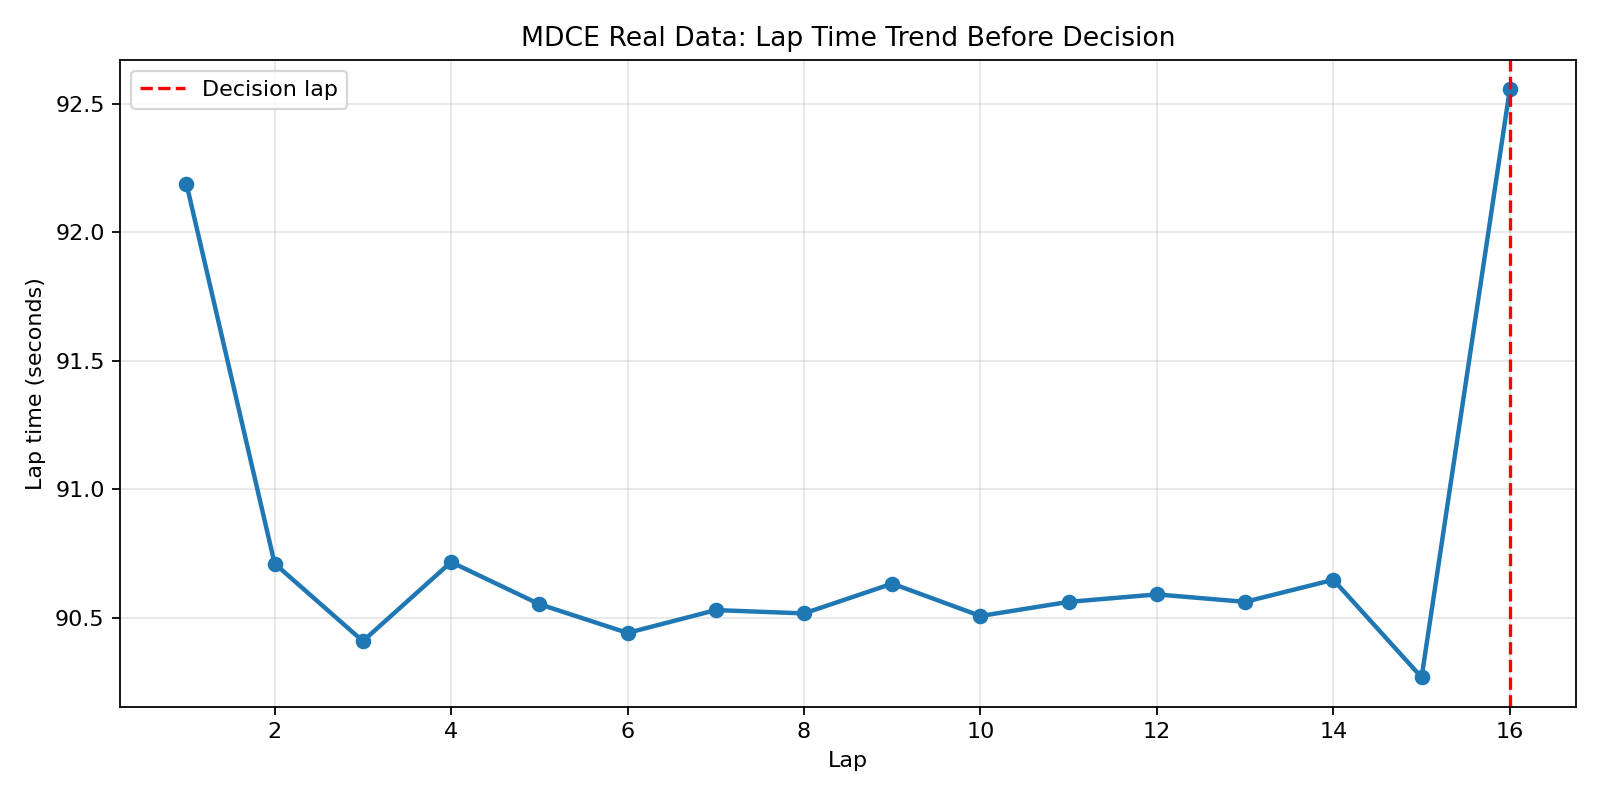

Chart: /content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/charts/confidence_by_scenario.png


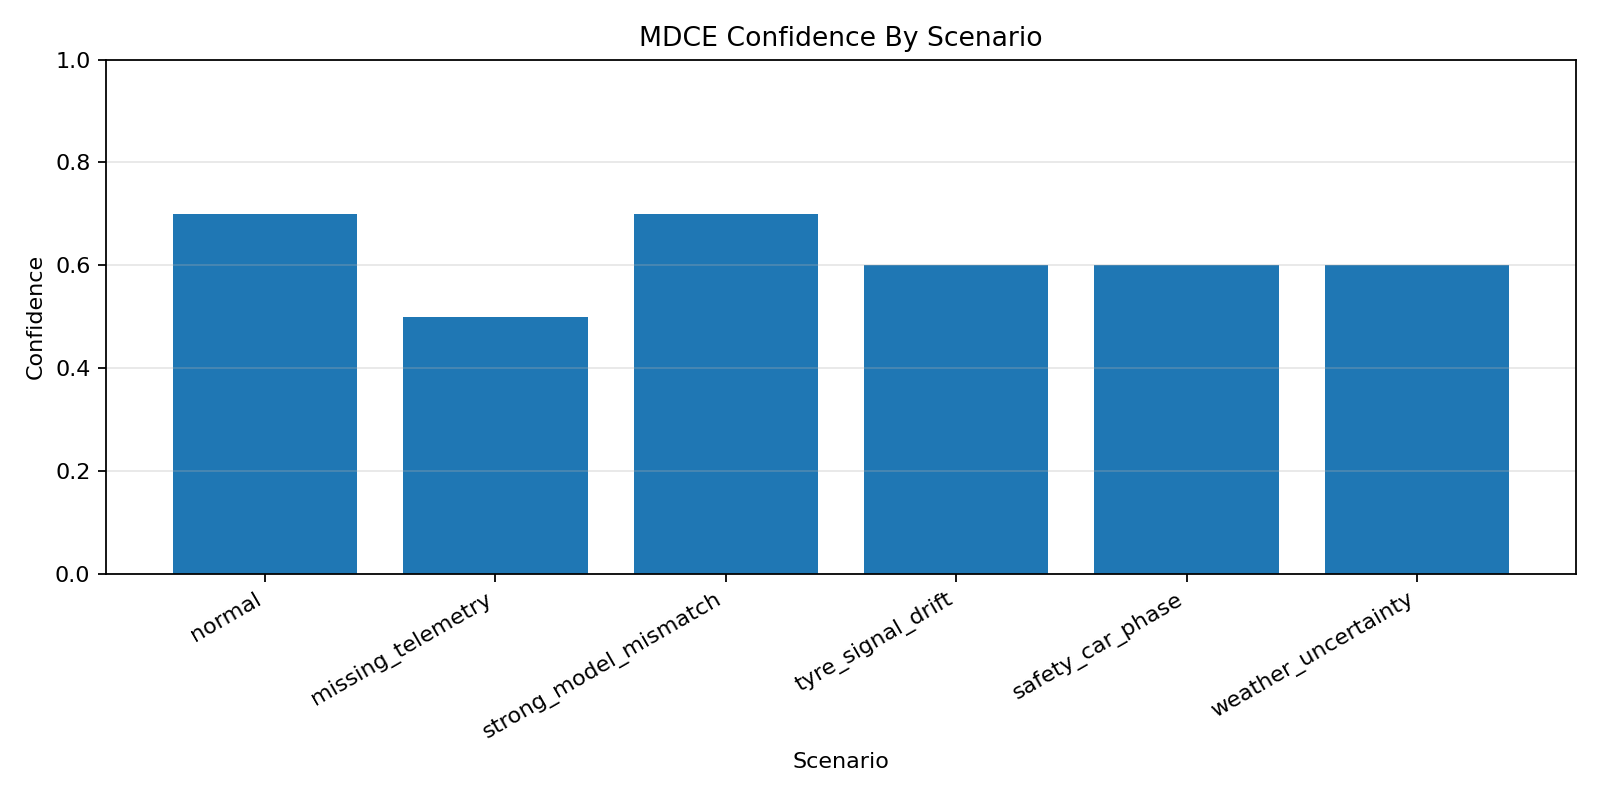

Chart: /content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/charts/actual_vs_predicted_trend.png


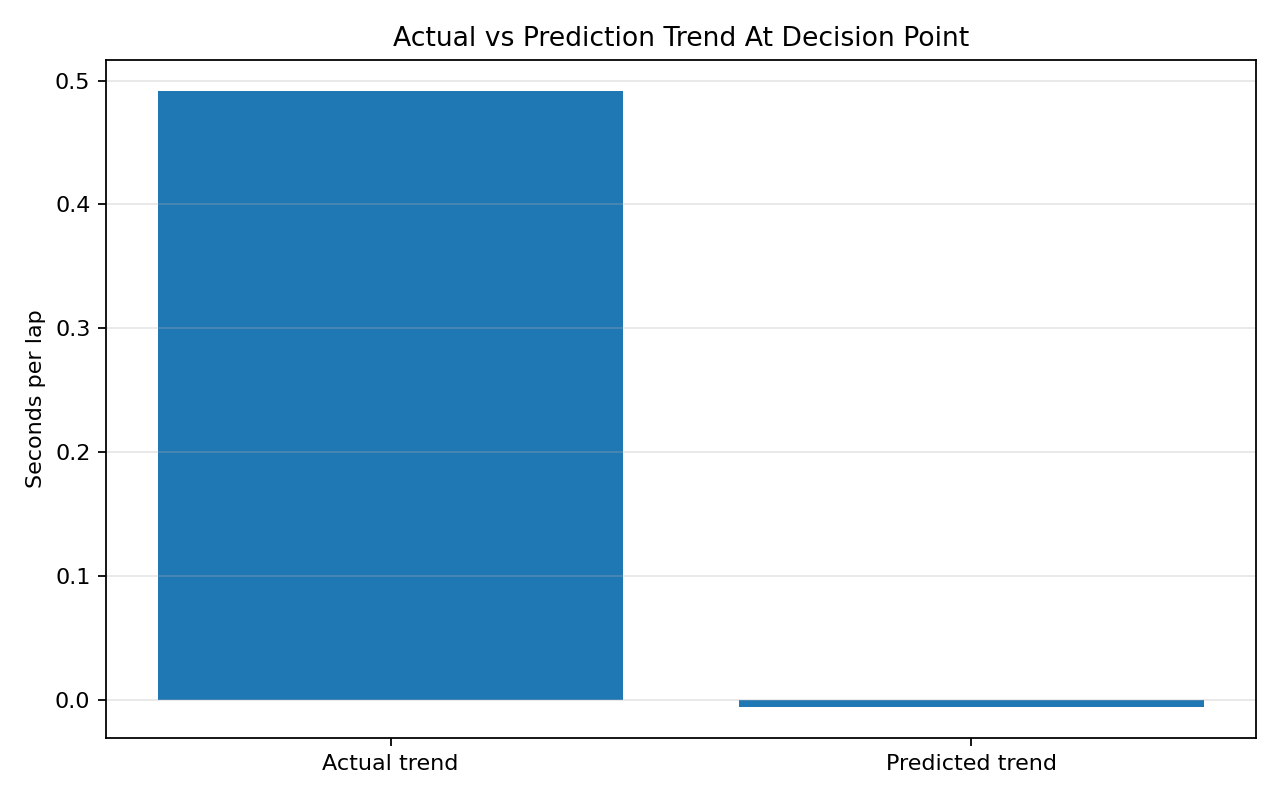

Chart: /content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/charts/pit_model_confusion_matrix.png


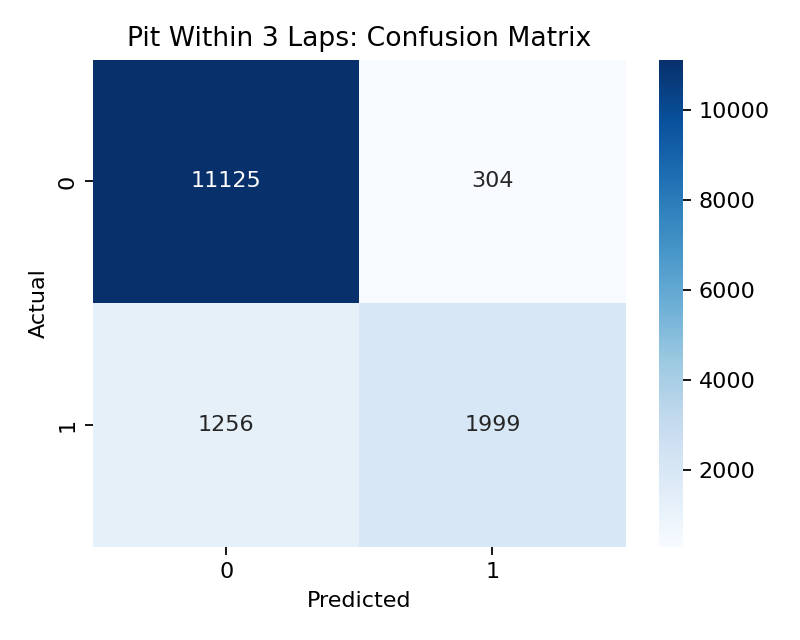

Chart: /content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/charts/pit_model_feature_importance.png


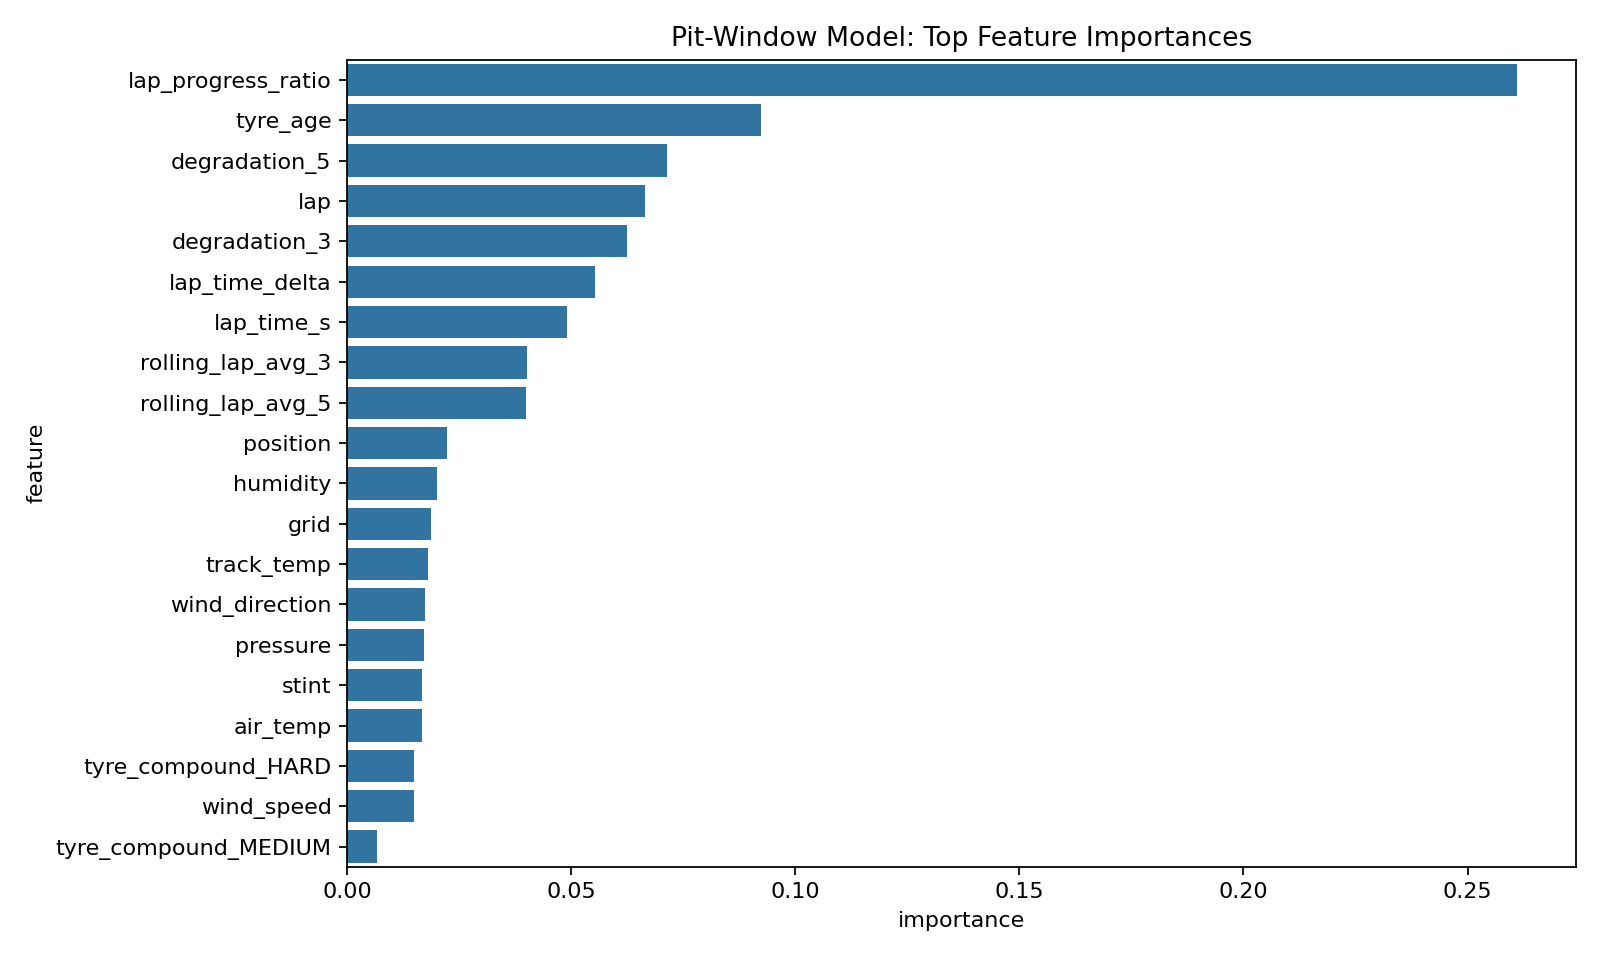

Chart: /content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/charts/ml_decision_event_lap_error.png


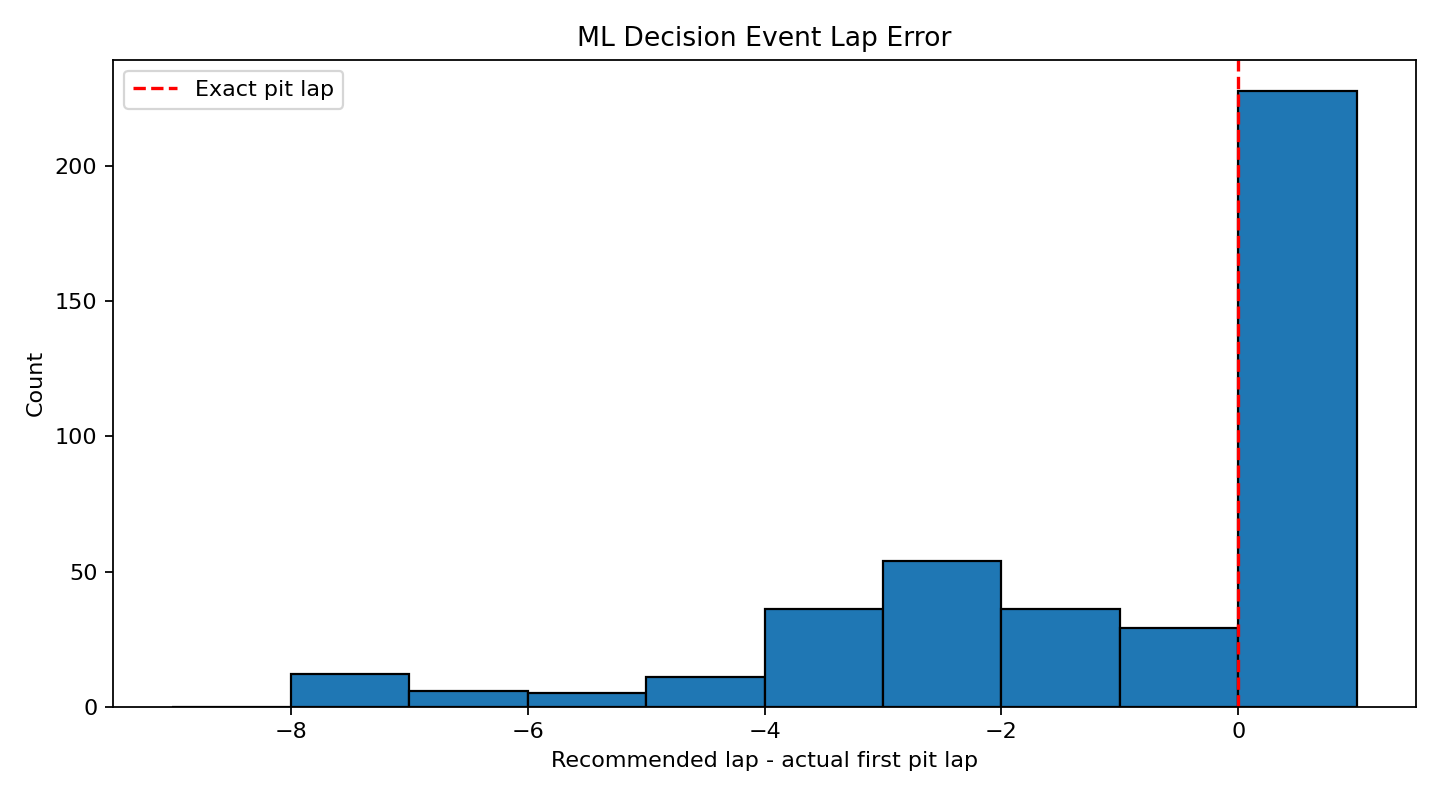

In [20]:
from pathlib import Path
from IPython.display import Markdown, Image, display
import pandas as pd

DRIVE_ROOT = Path('/content/drive/MyDrive/ibm_project_stuff/MDCE')
if not DRIVE_ROOT.exists():
    raise FileNotFoundError(
        f"Expected project folder not found: {DRIVE_ROOT}. "
        "This result viewer is intentionally locked to the MDCE folder."
    )

REPORT_DIR = DRIVE_ROOT / 'outputs' / 'reports'
CHART_DIR = DRIVE_ROOT / 'outputs' / 'charts'
MODEL_DIR = DRIVE_ROOT / 'outputs' / 'models'
DB_PATH = DRIVE_ROOT / 'databases' / 'mdce_f1.db'

print('Drive database:', DB_PATH)
print('Reports:', REPORT_DIR)
print('Charts:', CHART_DIR)
print('Model:', MODEL_DIR / 'pit_window_random_forest.joblib')

raw_inventory = REPORT_DIR / 'mdce_raw_upload_inventory.csv'
ingestion_audit = REPORT_DIR / 'mdce_ingestion_audit.csv'
if raw_inventory.exists():
    raw_df = pd.read_csv(raw_inventory)
    print('Raw uploaded files detected:', len(raw_df))
    display(raw_df.sort_values('size_mb', ascending=False).head(30))
if ingestion_audit.exists():
    ingest_df = pd.read_csv(ingestion_audit)
    print('Ingestion status counts:')
    print(ingest_df['status'].value_counts(dropna=False).to_string())
    display(ingest_df.sort_values(['status', 'size_mb'], ascending=[True, False]).head(50))

final_report = REPORT_DIR / 'mdce_final_evidence_report.md'
if final_report.exists():
    display(Markdown(final_report.read_text(encoding='utf-8')))
else:
    print('Missing final report:', final_report)

chart_names = [
    'lap_time_trend_decision.png',
    'confidence_by_scenario.png',
    'actual_vs_predicted_trend.png',
    'pit_model_confusion_matrix.png',
    'pit_model_feature_importance.png',
    'ml_decision_event_lap_error.png',
]
for name in chart_names:
    path = CHART_DIR / name
    if path.exists():
        print('Chart:', path)
        display(Image(filename=str(path)))
    else:
        print('Missing chart:', path)


## 5. What To Send Back

After the run finishes, send these outputs back in chat:

- The printed `AUTOPILOT COMPLETE` block.
- The ingestion status counts from `mdce_ingestion_audit.csv`.
- The JSON shown from `pit_model_metrics.json`.
- The JSON shown from `ml_decision_event_metrics.json`.
- Any error traceback if the notebook stops.

Do not manually edit generated reports before sending results. We need the real outputs to decide the next build step.
